# 02 — Text Preprocessing & Feature Engineering
**Fake News Detector** | Data Science Pipeline

Goals:
- Apply NLP preprocessing (lowercasing, stopword removal, lemmatization)
- Build TF-IDF feature matrix
- Visualise vocabulary statistics
- Save processed data to `data/processed/`

In [1]:
import sys, os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

## 1. Load & Preprocess

In [2]:
from src.preprocessing import load_dataset, normalise_labels, preprocess_text

df = load_dataset(data_dir='../data/raw')
df['label'] = normalise_labels(df['label'])
df = df.dropna(subset=['text', 'label'])
df = df[df['text'].str.strip() != '']

print(f'Loaded {len(df)} clean samples')
df.head(3)

Loaded 215 clean samples


,text,label
0,Secret documents show that NASA is hiding an E...,1
1,LEAKED MEMO: WHO plans to declare a global loc...,1
2,Government black helicopters are conducting se...,1


In [3]:
print('Preprocessing text (this may take a moment)...')
df['processed'] = df['text'].apply(preprocess_text)
df = df[df['processed'].str.len() > 0]
print(f'After preprocessing: {len(df)} samples')

# Before vs after comparison
sample = df.iloc[0]
print(f'\nOriginal  : {sample["text"][:120]}...')
print(f'Processed : {sample["processed"][:120]}...')

Preprocessing text (this may take a moment)...


After preprocessing: 215 samples

Original  : Secret documents show that NASA is hiding an Earth-like planet 4 light-years away with a thriving civilisation....
Processed : secret document show nasa hiding earth like planet light year away thriving civilisation...


## 2. Text Length Before vs After Preprocessing

Average token reduction after preprocessing: 33.4%


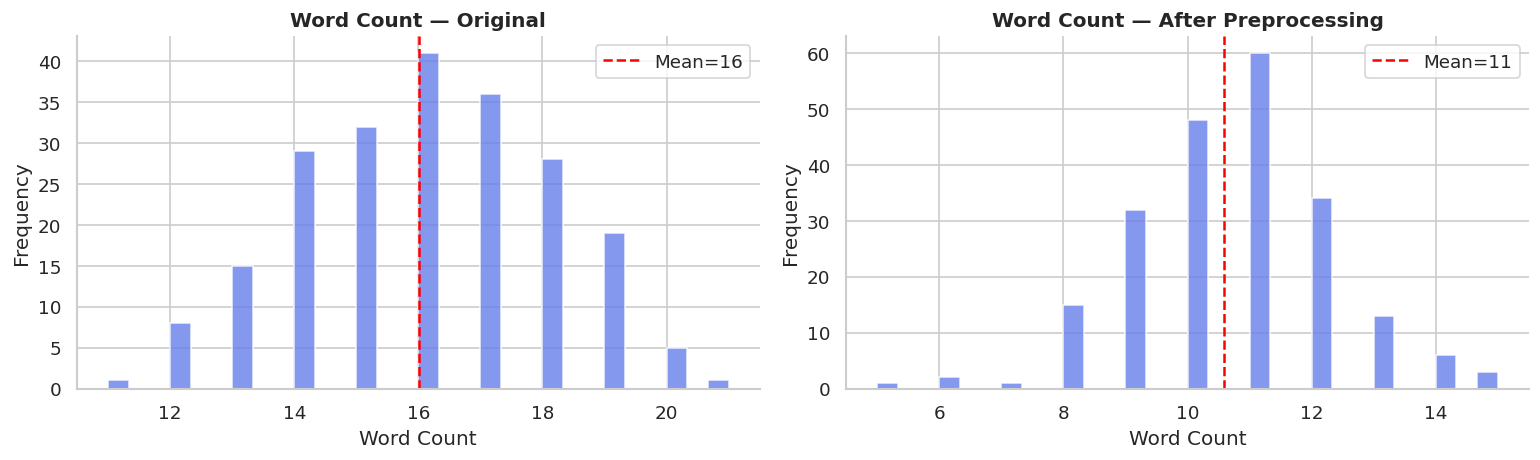

In [4]:
df['orig_len']  = df['text'].str.split().str.len()
df['proc_len']  = df['processed'].str.split().str.len()
df['reduction'] = (1 - df['proc_len'] / df['orig_len']) * 100

print(f'Average token reduction after preprocessing: {df["reduction"].mean():.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in zip(axes,
    ['orig_len', 'proc_len'],
    ['Word Count — Original', 'Word Count — After Preprocessing']):
    ax.hist(df[col], bins=30, color='#667eea', alpha=0.8, edgecolor='white')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean={df[col].mean():.0f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../reports/figures/preprocessing_comparison.png', bbox_inches='tight')
plt.show()

## 3. Train/Test Split

In [5]:
X = df['processed']
y = df['label'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {len(X_train)}  |  Test : {len(X_test)}')
print(f'Train label balance: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Test  label balance: {y_test.value_counts(normalize=True).round(3).to_dict()}')

Train : 172  |  Test : 43
Train label balance: {1: 0.512, 0: 0.488}
Test  label balance: {1: 0.512, 0: 0.488}


## 4. TF-IDF Vectorization

In [6]:
from src.features import build_vectorizer, vectorize

vectorizer = build_vectorizer(max_features=15000, ngram_range=(1, 2))
X_tr_tfidf, X_te_tfidf = vectorize(vectorizer, X_train, X_test)

print(f'Vocabulary size  : {len(vectorizer.get_feature_names_out()):,}')
print(f'Train matrix     : {X_tr_tfidf.shape}')
print(f'Test  matrix     : {X_te_tfidf.shape}')
print(f'Matrix sparsity  : {1 - X_tr_tfidf.nnz / (X_tr_tfidf.shape[0]*X_tr_tfidf.shape[1]):.4f}')

Vocabulary size  : 2,755
Train matrix     : (172, 2755)
Test  matrix     : (43, 2755)
Matrix sparsity  : 0.9927


## 5. Top TF-IDF Terms by Class

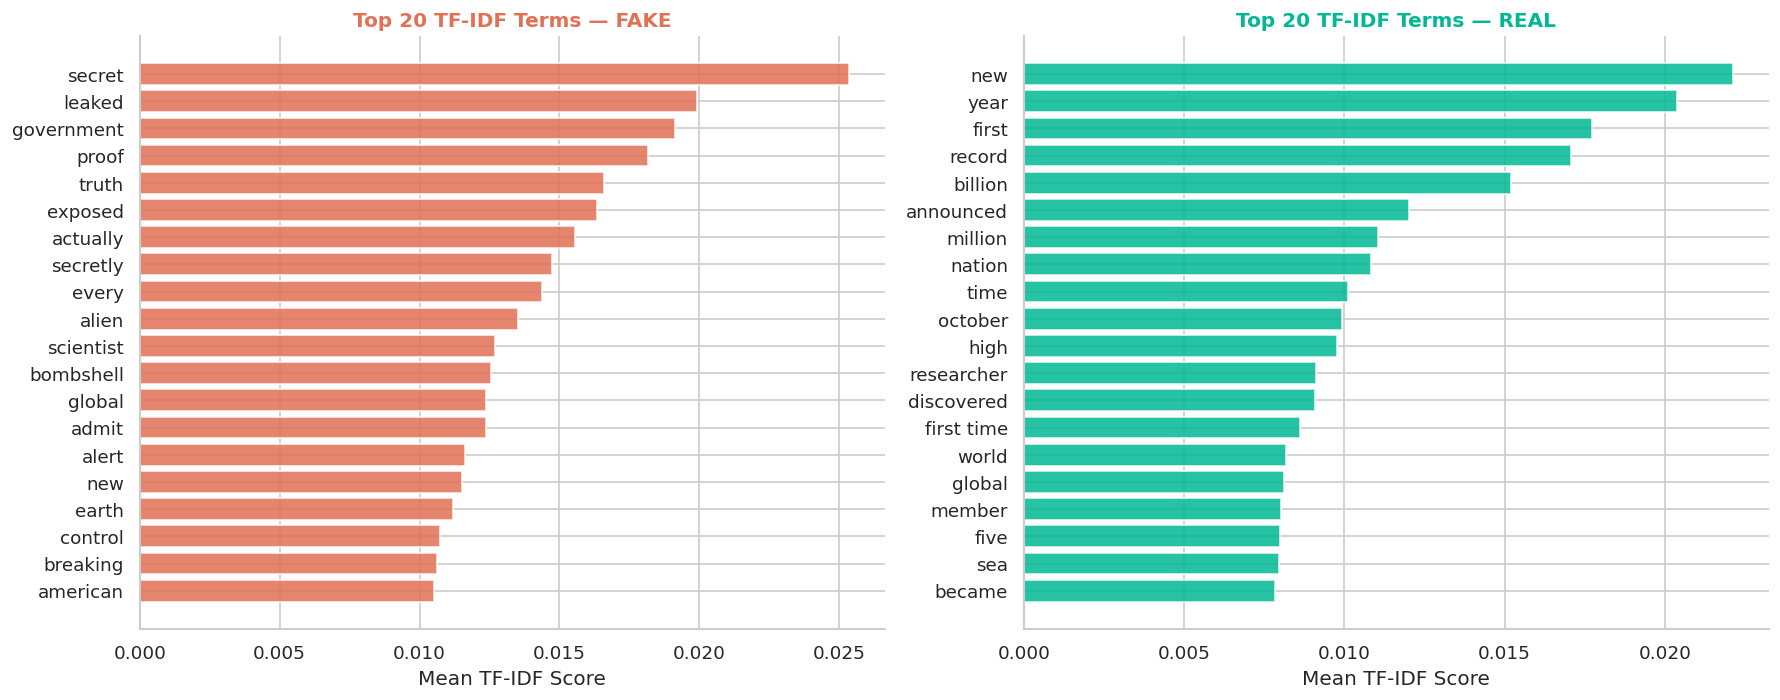

In [7]:
features = vectorizer.get_feature_names_out()
tfidf_df  = pd.DataFrame(X_tr_tfidf.toarray(), columns=features)
tfidf_df['label'] = y_train.values

fake_means = tfidf_df[tfidf_df.label == 1].drop('label', axis=1).mean().nlargest(20)
real_means = tfidf_df[tfidf_df.label == 0].drop('label', axis=1).mean().nlargest(20)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, series, title, color in zip(axes,
    [fake_means, real_means],
    ['Top 20 TF-IDF Terms — FAKE', 'Top 20 TF-IDF Terms — REAL'],
    ['#e17055', '#00b894']):
    ax.barh(series.index[::-1], series.values[::-1], color=color, alpha=0.85)
    ax.set_title(title, fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Mean TF-IDF Score')
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../reports/figures/tfidf_top_terms.png', bbox_inches='tight')
plt.show()

## 6. Save Processed Data

In [8]:
import pickle

os.makedirs('../data/processed', exist_ok=True)

splits = {'X_train': X_train, 'X_test': X_test, 'y_train': y_train, 'y_test': y_test}
with open('../data/processed/train_test_split.pkl', 'wb') as f:
    pickle.dump(splits, f)

with open('../data/processed/vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print('Saved to data/processed/')
print('  train_test_split.pkl')
print('  vectorizer.pkl')

Saved to data/processed/
  train_test_split.pkl
  vectorizer.pkl
